In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load the data

In [59]:
df_products= pd.read_parquet('../dataset/cleaned/products.parquet')
df_order_items= pd.read_parquet('../dataset/cleaned/order_items.parquet')
df_orders = pd.read_parquet('../dataset/cleaned/orders.parquet')
df_promos = pd.read_parquet('../dataset/cleaned/promotions.parquet')

### Merged file

In [60]:
df_merged= pd.merge(df_products, df_order_items, on='product_id', how='left')
df_final = df_merged.merge(df_promos, on='promo_id', how='left')
df_master = df_final.merge(df_orders[['order_id', 'order_date']], on='order_id', how='left')
df_master = df_master.rename(columns={'order_date': 'Date'})
print("Kích thước bảng Master:", df_master.shape)
display(df_master.head())

Kích thước bảng Master: (715483, 24)


,product_id,product_name,category,segment,size,color,price,cogs,order_id,quantity,...,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value,Date
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245451,5.0,...,<NA>,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2015-01-07
1,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245898,8.0,...,<NA>,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2015-01-13
2,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246268,6.0,...,<NA>,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2015-01-13
3,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246907,2.0,...,<NA>,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2015-01-17
4,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,247911,6.0,...,<NA>,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2015-01-24


# 2. EDA

In [61]:
check_promo = df_final[df_final['promo_name'].notna()]
print(f"Tổng số dòng có thông tin khuyến mãi: {len(check_promo)}")
display(check_promo.head())

Tổng số dòng có thông tin khuyến mãi: 276316


,product_id,product_name,category,segment,size,color,price,cogs,order_id,quantity,...,promo_id_2,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
14,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,259871,1.0,...,None,Spring Sale 2015,percentage,12.0,2015-03-18,2015-04-17,All,all_channels,1.0,100000.0
15,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,268094,6.0,...,None,Spring Sale 2015,percentage,12.0,2015-03-18,2015-04-17,All,all_channels,1.0,100000.0
16,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,268430,8.0,...,None,Spring Sale 2015,percentage,12.0,2015-03-18,2015-04-17,All,all_channels,1.0,100000.0
26,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,299601,3.0,...,None,Mid-Year Sale 2015,percentage,18.0,2015-06-23,2015-07-22,All,social_media,0.0,0.0
27,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254,523256,7.0,...,None,Urban Blowout 2017,fixed,50.0,2017-07-30,2017-09-02,Streetwear,online,0.0,150000.0


In [62]:
print("Tổng số sản phẩm sau khi merge:", len(df_master))
print("Số lượng đơn hàng có Date:", df_master['Date'].notnull().sum())
print(f"=> Phát hiện: {len(df_master) - df_master['Date'].notnull().sum()} sản phẩm chưa bao giờ được bán.")

Tổng số sản phẩm sau khi merge: 715483
Số lượng đơn hàng có Date: 714669
=> Phát hiện: 814 sản phẩm chưa bao giờ được bán.


### Insight: Có 814 "sản phẩm ma" (Deadstock). Chúng ta cần loại bỏ chúng để dữ liệu dự báo không bị nhiễu.

In [63]:
df_master = df_master.dropna(subset=['Date']).reset_index(drop=True)
print("Kích thước bảng thực tế:", df_master.shape)

Kích thước bảng thực tế: (714669, 24)


In [64]:
# Xem kiểu dữ liệu đã đúng hết chưa
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714669 entries, 0 to 714668
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   product_id           714669 non-null  string        
 1   product_name         714669 non-null  string        
 2   category             714669 non-null  category      
 3   segment              714669 non-null  category      
 4   size                 714669 non-null  category      
 5   color                714669 non-null  category      
 6   price                714669 non-null  float64       
 7   cogs                 714669 non-null  float64       
 8   order_id             714669 non-null  string        
 9   quantity             714669 non-null  float64       
 10  unit_price           714669 non-null  float64       
 11  discount_amount      714669 non-null  float64       
 12  promo_id             714669 non-null  string        
 13  promo_id_2    

In [65]:
# Tính các phần doanh thu, giá nhập, lợi nhuân
df_master['Revenue_line'] = df_master['quantity'] * df_master['unit_price'] - df_master['discount_amount']
df_master['COGS_line'] = df_master['quantity'] * df_master['cogs']
df_master['Profit_line'] = df_master['Revenue_line'] - df_master['COGS_line']

display(df_master[['product_name', 'quantity', 'unit_price', 'cogs', 'Revenue_line', 'Profit_line']].head())

,product_name,quantity,unit_price,cogs,Revenue_line,Profit_line
0,SaigonFlex UC-01,5.0,11183.67,9704.842875,55918.35,7394.135625
1,SaigonFlex UC-01,8.0,10918.75,9704.842875,87350.00,9711.257000
2,SaigonFlex UC-01,6.0,11184.55,9704.842875,67107.30,8878.242750
3,SaigonFlex UC-01,2.0,11104.72,9704.842875,22209.44,2799.754250
4,SaigonFlex UC-01,6.0,11143.16,9704.842875,66858.96,8629.902750


/var/folders/z7/rzx5mnrn2l7fw6scbxh1jxc40000gn/T/ipykernel_69578/1603396284.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_data = df_master.groupby('category')[['Revenue_line', 'Profit_line']].sum().reset_index()


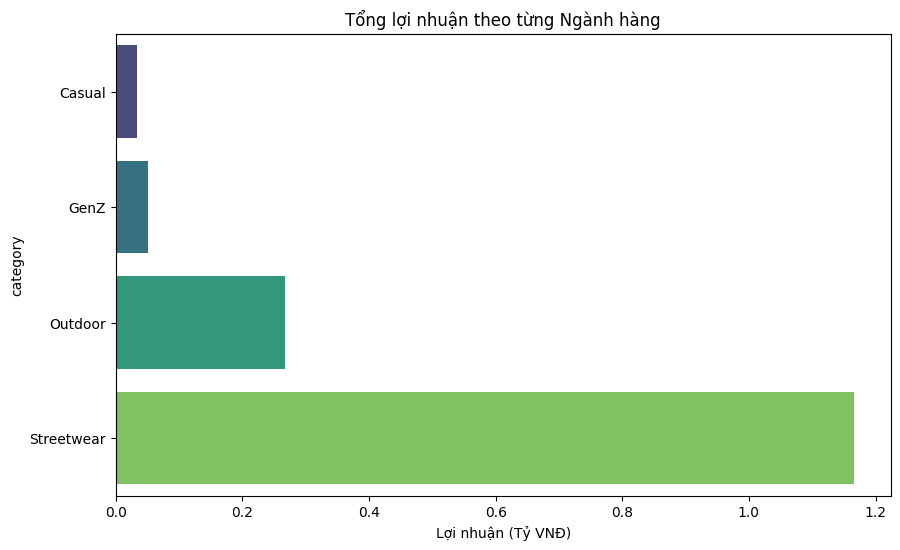

In [66]:
# Xem lợi nhuận của phần Cat nào cao nhất
cat_data = df_master.groupby('category')[['Revenue_line', 'Profit_line']].sum().reset_index()
cat_data = cat_data.sort_values('Profit_line', ascending=False)
cat_data['Profit_Billion'] = cat_data['Profit_line'] / 1e9

plt.figure(figsize=(10, 6))
sns.barplot(data=cat_data, x='Profit_Billion', y='category', hue='category', palette='viridis', legend=False)
plt.title('Tổng lợi nhuận theo từng Ngành hàng')
plt.xlabel('Lợi nhuận (Tỷ VNĐ)')
plt.show()

### As illustrated in the bar chart, the Streetwear category accounts for the lion's share of total profit, reaching approximately 1.17 billion VND. My team suggested focusing the marketing budget on this segment to optimize cash flow.

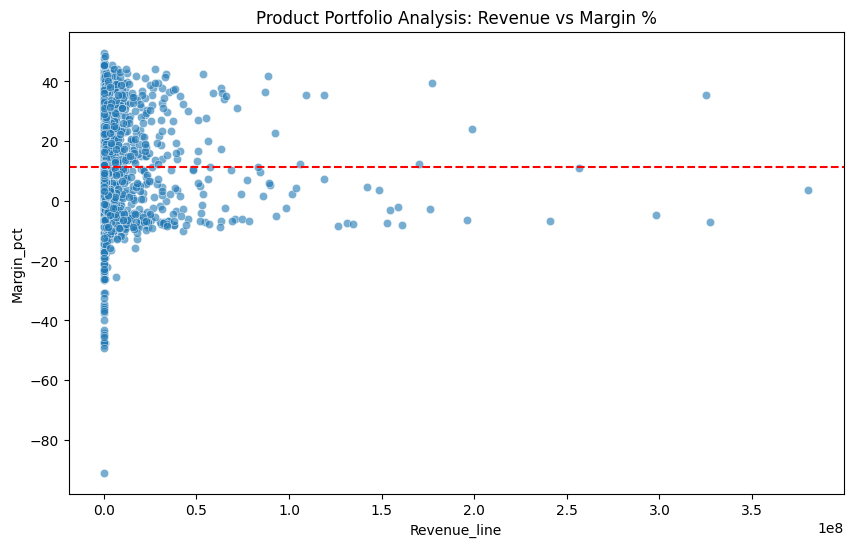

In [67]:
prod_analysis = df_master.groupby('product_name').agg({
    'Revenue_line': 'sum',
    'Profit_line': 'sum'
}).reset_index()
prod_analysis['Margin_pct'] = (prod_analysis['Profit_line'] / prod_analysis['Revenue_line']) * 100

plt.figure(figsize=(10, 6))
sns.scatterplot(data=prod_analysis, x='Revenue_line', y='Margin_pct', alpha=0.6)
plt.axhline(prod_analysis['Margin_pct'].mean(), color='red', linestyle='--', label='Average Margin')
plt.title('Product Portfolio Analysis: Revenue vs Margin %')
plt.show()

### The scatter plot reveals a significant disparity in product performance. While the majority of items are clustered in the low-revenue zone, a few outliers stand out as high-performers with profit margins exceeding the mean of approximately 16%. Notably, there is a concerning anomaly in the bottom-left quadrant exhibiting a negative margin of nearly -80%, which warrants further investigation into potential pricing errors or aggressive discounting strategies.

In [68]:
# Kiểm tra ouliers
outlier = prod_analysis.sort_values('Margin_pct').head(1)
display(outlier)

,product_name,Revenue_line,Profit_line,Margin_pct
1325,VietMode UR-02,15606.06,-14192.058,-90.939404


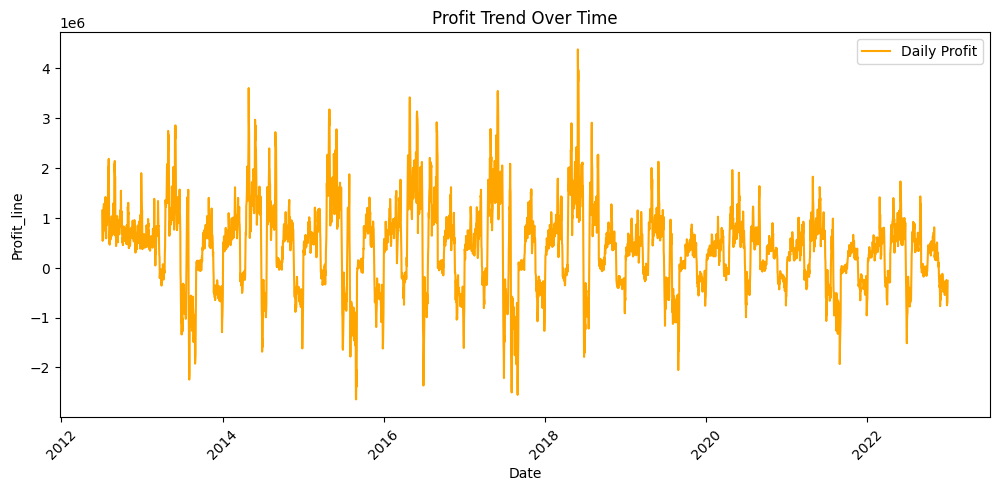

In [69]:
daily_trend = df_master.groupby('Date')[['Revenue_line', 'Profit_line']].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_trend, x='Date', y='Profit_line', color='orange', label='Daily Profit')
plt.title('Profit Trend Over Time')
plt.xticks(rotation=45)
plt.show()

### The line chart illustrates the **daily profit fluctuations** over a decade. It is palpably evident that the business experiences **extreme volatility**, characterized by frequent peaks and significant "dips" where profit plummets into negative territory. 

* **Seasonality:** The recurring spikes suggest a strong seasonal pattern, possibly linked to annual shopping festivals or holiday seasons.
* **Anomalies:** Several "deep dips" (negative profit) are observed periodically. These could be attributed to **aggressive loss-leader strategies** or major clearance sales aimed at inventory turnover rather than immediate margin.
* **Overall Trend:** Despite the volatility, the business maintains a relatively stable baseline, though a slight saturation is visible in the latter years (2020-2022).

# 3.Feature Engineering

In [70]:
df_master['day_of_week'] = df_master['Date'].dt.dayofweek
df_master['month'] = df_master['Date'].dt.month
df_master['is_weekend'] = df_master['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

In [71]:
# Do discount_value có 2 dạng là fixed và percentage nên ta sẽ chuyển hết về percentage
df_master['discount_value'].value_counts()
df_master['discount_pct'] = 0.0
# Đặt biến mặt nạ mask để lọc ra 2 loại là fixed và percentage
mask_pct = df_master['promo_type'] == 'percentage'
mask_fixed = df_master['promo_type'] == 'fixed'
# Định vị các cột discount_value nếu percentage thì chia 100 để lấy số thập phân, nếu fixed thì lấy số tiền giamr giá chia cho giá tiền
df_master.loc[mask_pct, 'discount_pct'] = df_master.loc[mask_pct, 'discount_value'] / 100
df_master.loc[mask_fixed, 'discount_pct'] = df_master.loc[mask_fixed, 'discount_value'] / df_master.loc[mask_fixed, 'price']
df_master['discount_pct'] = df_master['discount_pct'].clip(0, 1)
print("Các giá trị discount_pct sau khi tính toán:")
print(df_master['discount_pct'].value_counts().head(10))

Các giá trị discount_pct sau khi tính toán:
discount_pct
0.000000    438353
0.200000     71799
0.120000     71591
0.180000     57417
0.100000     45654
0.150000      8905
0.008532       460
0.003840       459
0.008978       404
0.008150       401
Name: count, dtype: int64


In [72]:
df_master['discount_pct_mean'] = df_master['discount_pct'] 
df_master['discount_pct_max'] = df_master['discount_pct']  


In [73]:
df_daily = df_master.groupby('Date').agg({
    'Revenue_line': 'sum',   
    'day_of_week': 'first',
    'is_weekend': 'first',
}).reset_index()

### Feature Engineering Strategy:
* To surpass the established baseline, we implemented a robust feature engineering pipeline. Beyond basic temporal variables like day_of_week and is_weekend, we introduced Lag Features (Lag 1​ and Lag 7) to capture the autocorrelation inherent in sales data. Furthermore, by encoding promotion status, the model can now distinguish between natural demand and artificially inflated sales driven by marketing campaigns.

In [74]:
# One-Hot Encoding cho Category & Segment
df_encoded = pd.get_dummies(df_master, columns=['category', 'segment'], prefix=['cat', 'seg'])
# Lấy danh sách các cột vừa mới tạo ra từ One-Hot
encoded_cols = [col for col in df_encoded.columns if col.startswith(('cat_', 'seg_'))]

In [75]:
# Với các cột One-Hot, chúng ta dùng 'sum' để biết ngày đó bán được bao nhiêu món thuộc loại đó
agg_logic = {
    'Revenue_line': 'sum',
    'Profit_line': 'sum', 
    'day_of_week': 'first',
    'month': 'first',
    'is_weekend': 'first',
    'discount_pct_mean' : 'mean',
    'discount_pct_max' : 'max'
}
# Thêm các cột encoded vào logic tính tổng
for col in encoded_cols:
    agg_logic[col] = 'sum'
df_daily = df_encoded.groupby('Date').agg(agg_logic).reset_index()
df_daily.columns = ['_'.join(col) if isinstance(col, tuple) else col for col in df_daily.columns]
# Lag Features
# Model sẽ nhìn vào kết quả của 1 ngày và 7 ngày trước đó để dự báo
df_daily = df_daily.sort_values('Date')
df_daily['rev_lag_1'] = df_daily['Revenue_line'].shift(1)
df_daily['rev_lag_7'] = df_daily['Revenue_line'].shift(7)
df_daily['rev_lag_365'] = df_daily['Revenue_line'].shift(365)
df_daily['margin_rate']= df_daily['Profit_line'] / (df_daily['Revenue_line']+1)
df_daily['margin_rate_lag_7']= df_daily['margin_rate'].shift(7)
df_daily['margin_rate_lag_365']= df_daily['margin_rate'].shift(365)
df_daily['profit_lag_7'] = df_daily['Profit_line'].shift(7)
df_daily['profit_lag_365'] = df_daily['Profit_line'].shift(365)
# Cuối cùng là lấp đầy các giá trị NaN do hàm shift tạo ra
df_daily = df_daily.fillna(0)

# Đổi tên cho đúng format
df_daily = df_daily.rename(columns={'Revenue_line': 'Revenue', 'Profit_line': 'Profit'})
df_daily = df_daily.rename(columns={'discount_pct_mean': 'avg_discount_pct', 'discount_pct_max': 'max_discount_pct'})
df_daily['COGS'] = df_daily['Revenue'] - df_daily['Profit']
print("Kích thước bảng Daily:", df_daily.shape)
display(df_daily.head())

Kích thước bảng Daily: (3833, 29)


,Date,Revenue,Profit,day_of_week,month,is_weekend,avg_discount_pct,max_discount_pct,cat_Casual,cat_GenZ,...,seg_Trendy,rev_lag_1,rev_lag_7,rev_lag_365,margin_rate,margin_rate_lag_7,margin_rate_lag_365,profit_lag_7,profit_lag_365,COGS
0,2012-07-04,5123547.94,1.140557e+06,2,7,0,0.0,0.0,5,7,...,7,0.00,0.0,0.0,0.222611,0.0,0.0,0.0,0.0,3.982991e+06
1,2012-07-05,2751773.45,6.011932e+05,3,7,0,0.0,0.0,1,7,...,7,5123547.94,0.0,0.0,0.218475,0.0,0.0,0.0,0.0,2.150580e+06
2,2012-07-06,3054029.42,5.363966e+05,4,7,0,0.0,0.0,3,5,...,5,2751773.45,0.0,0.0,0.175636,0.0,0.0,0.0,0.0,2.517633e+06
3,2012-07-07,2667930.94,5.596843e+05,5,7,1,0.0,0.0,1,1,...,1,3054029.42,0.0,0.0,0.209782,0.0,0.0,0.0,0.0,2.108247e+06
4,2012-07-08,2360851.90,5.522291e+05,6,7,1,0.0,0.0,0,6,...,6,2667930.94,0.0,0.0,0.233911,0.0,0.0,0.0,0.0,1.808623e+06


In [76]:
df_daily['year'] = df_daily['Date'].dt.year
df_daily['month_day'] = df_daily['Date'].dt.strftime('%m-%d')

# Xác định từng loại khuyến mãi (biến boolean tạm)
is_spring = df_daily['month_day'].between('03-18', '04-17')
is_midyear = df_daily['month_day'].between('06-23', '07-22')
is_fall = (df_daily['month_day'].between('08-30', '10-01') | 
           ((df_daily['year'] % 4 == 1) & (df_daily['month_day'] == '10-02')))
is_yearend = (df_daily['month_day'].between('11-18', '12-31') | 
              df_daily['month_day'].between('01-01', '01-02'))
is_rural = ((df_daily['year'] % 2 == 1) & 
            df_daily['month_day'].between('01-30', '03-01'))
is_urban = ((df_daily['year'] % 2 == 1) & 
            df_daily['month_day'].between('07-30', '09-02'))

# Tạo biến tổng quát
df_daily['is_any_promotion'] = (is_spring | is_midyear | is_fall | 
                                  is_yearend | is_rural | is_urban).astype(int)

df_daily['num_active_promos'] = (is_spring.astype(int) + is_midyear.astype(int) + 
                                   is_fall.astype(int) + is_yearend.astype(int) + 
                                   is_rural.astype(int) + is_urban.astype(int))

df_daily['is_major_sale'] = (is_spring | is_midyear | is_yearend).astype(int)
df_daily['is_minor_sale'] = (is_fall | is_rural | is_urban).astype(int)

# Kênh khuyến mãi
df_daily['chanel_promotion'] = -1
df_daily.loc[is_spring | is_fall, 'chanel_promotion'] = 4
df_daily.loc[is_rural, 'chanel_promotion'] = 1
df_daily.loc[is_urban, 'chanel_promotion'] = 2
df_daily.loc[is_midyear, 'chanel_promotion'] = 3
df_daily.loc[is_yearend, 'chanel_promotion'] = 0

# Xóa cột tạm
df_daily = df_daily.drop(columns=['year', 'month_day'])

In [77]:
df_daily.to_parquet('../dataset/processed_data_daily.parquet', index=False)
print("Đã xuất file Parquet thành công!")

Đã xuất file Parquet thành công!
